In [15]:
%pip install seaborn

In [16]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("world-happiness-report-2021.csv")

In [17]:
#Data Processing & Cleaning

# Check for null values
df.isnull().sum()


# Drop rows or fill missing values
df = df.dropna()  # OR df.fillna(method='ffill', inplace=True)

# Check data types
df.dtypes

# Rename columns for easier use
df.rename(columns={
    'Country name': 'Country',
    'Ladder score': 'Happiness Score',
    'Logged GDP per capita': 'GDP',
    'Healthy life expectancy': 'Life Expectancy'
}, inplace=True)

df.head()


,Country,Regional indicator,Happiness Score,Standard error of ladder score,upperwhisker,lowerwhisker,GDP,Social support,Life Expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Ladder score in Dystopia,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
0,Finland,Western Europe,7.842,0.032,7.904,7.780,10.775,0.954,72.0,0.949,-0.098,0.186,2.43,1.446,1.106,0.741,0.691,0.124,0.481,3.253
1,Denmark,Western Europe,7.620,0.035,7.687,7.552,10.933,0.954,72.7,0.946,0.030,0.179,2.43,1.502,1.108,0.763,0.686,0.208,0.485,2.868
2,Switzerland,Western Europe,7.571,0.036,7.643,7.500,11.117,0.942,74.4,0.919,0.025,0.292,2.43,1.566,1.079,0.816,0.653,0.204,0.413,2.839
3,Iceland,Western Europe,7.554,0.059,7.670,7.438,10.878,0.983,73.0,0.955,0.160,0.673,2.43,1.482,1.172,0.772,0.698,0.293,0.170,2.967
4,Netherlands,Western Europe,7.464,0.027,7.518,7.410,10.932,0.942,72.4,0.913,0.175,0.338,2.43,1.501,1.079,0.753,0.647,0.302,0.384,2.798


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149 entries, 0 to 148
Data columns (total 20 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Country                                     149 non-null    object 
 1   Regional indicator                          149 non-null    object 
 2   Happiness Score                             149 non-null    float64
 3   Standard error of ladder score              149 non-null    float64
 4   upperwhisker                                149 non-null    float64
 5   lowerwhisker                                149 non-null    float64
 6   GDP                                         149 non-null    float64
 7   Social support                              149 non-null    float64
 8   Life Expectancy                             149 non-null    float64
 9   Freedom to make life choices                149 non-null    float64
 10  Generosity    

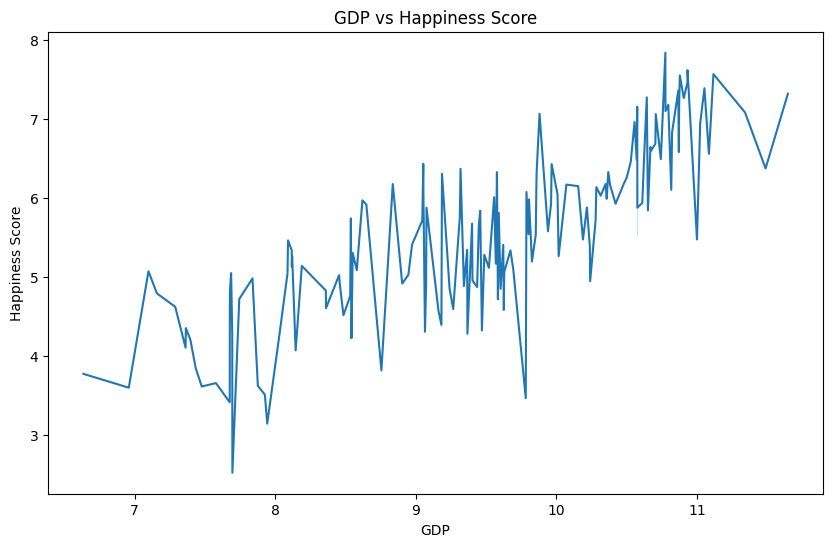

<Figure size 640x480 with 0 Axes>

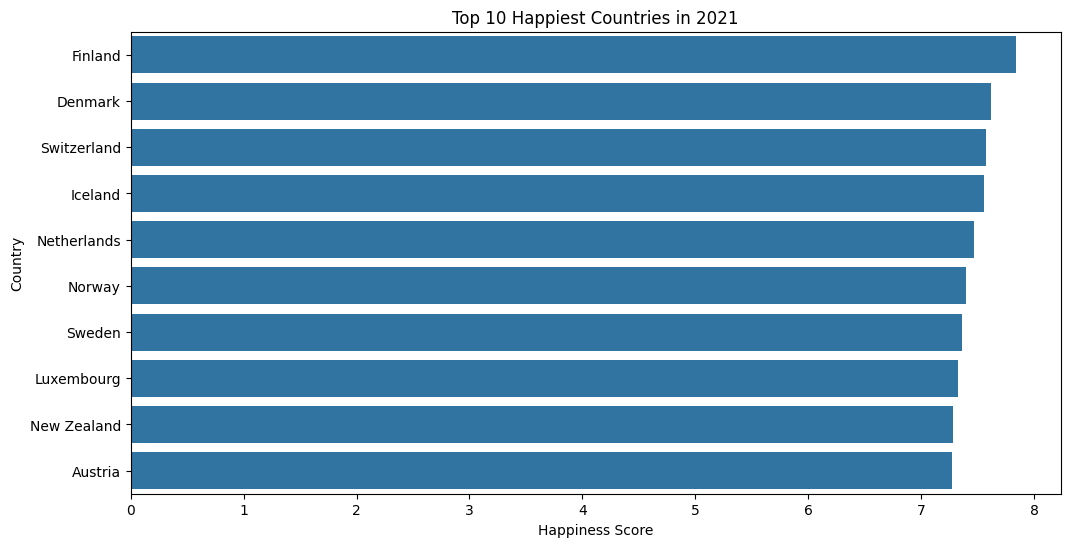

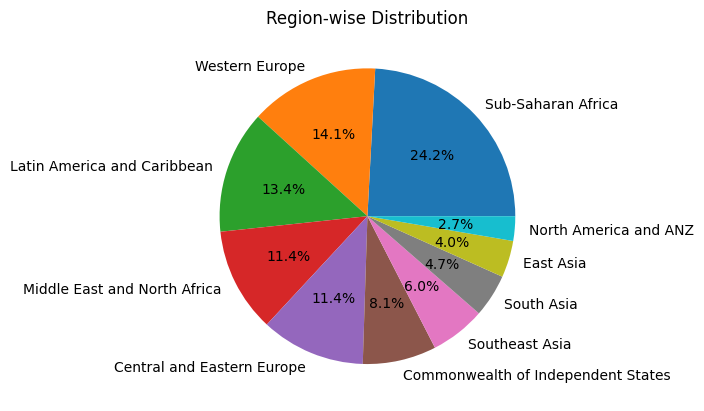

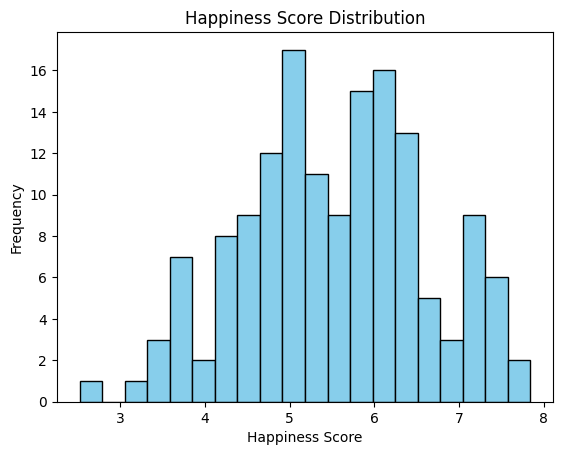

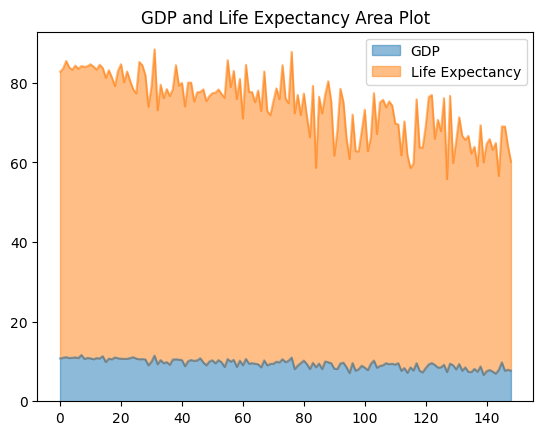

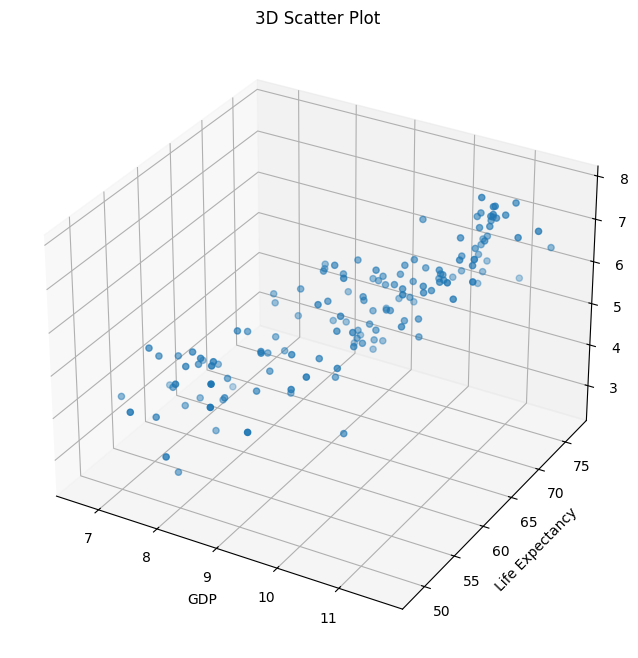

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Line Chart: GDP vs Happiness
plt.figure(figsize=(10,6))
sns.lineplot(x='GDP', y='Happiness Score', data=df)
plt.title('GDP vs Happiness Score')
plt.show()
plt.savefig('line_chart.png')  # Save as PNG

# Bar Plot: Top 10 Happiest Countries
top10 = df.sort_values('Happiness Score', ascending=False).head(10)
plt.figure(figsize=(12,6))
sns.barplot(x='Happiness Score', y='Country', data=top10)
plt.title('Top 10 Happiest Countries in 2021')
plt.show()


# Pie Chart: Region wise country distribution (if 'Regional indicator' column exists)
df['Regional indicator'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title('Region-wise Distribution')
plt.ylabel('')
plt.show()

# Histogram: Distribution of Happiness Score
plt.hist(df['Happiness Score'], bins=20, color='skyblue', edgecolor='black')
plt.title('Happiness Score Distribution')
plt.xlabel('Happiness Score')
plt.ylabel('Frequency')
plt.show()

# Area Plot: GDP, Life Expectancy
df[['GDP', 'Life Expectancy']].plot(kind='area', alpha=0.5)
plt.title('GDP and Life Expectancy Area Plot')
plt.show()

# 3D Plot: (if using plotly or matplotlib's mpl_toolkits)
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df['GDP'], df['Life Expectancy'], df['Happiness Score'])
ax.set_xlabel('GDP')
ax.set_ylabel('Life Expectancy')
ax.set_zlabel('Happiness Score')
plt.title('3D Scatter Plot')
plt.show()


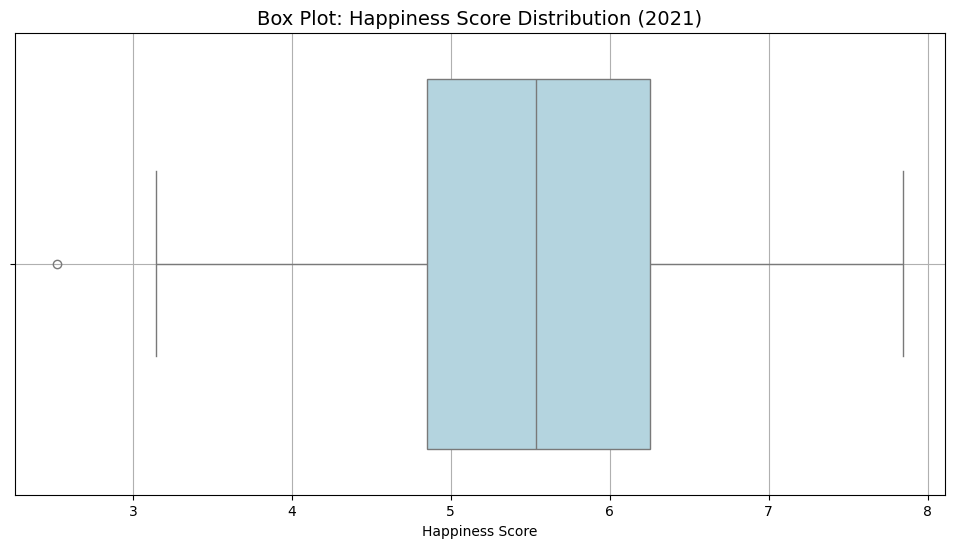

In [20]:
#box plot
# Set the figure size
plt.figure(figsize=(12,6))

# Boxplot for 'Happiness Score'
sns.boxplot(x=df['Happiness Score'], color='lightblue')
plt.title('Box Plot: Happiness Score Distribution (2021)', fontsize=14)
plt.xlabel('Happiness Score')
plt.grid(True)
plt.show()


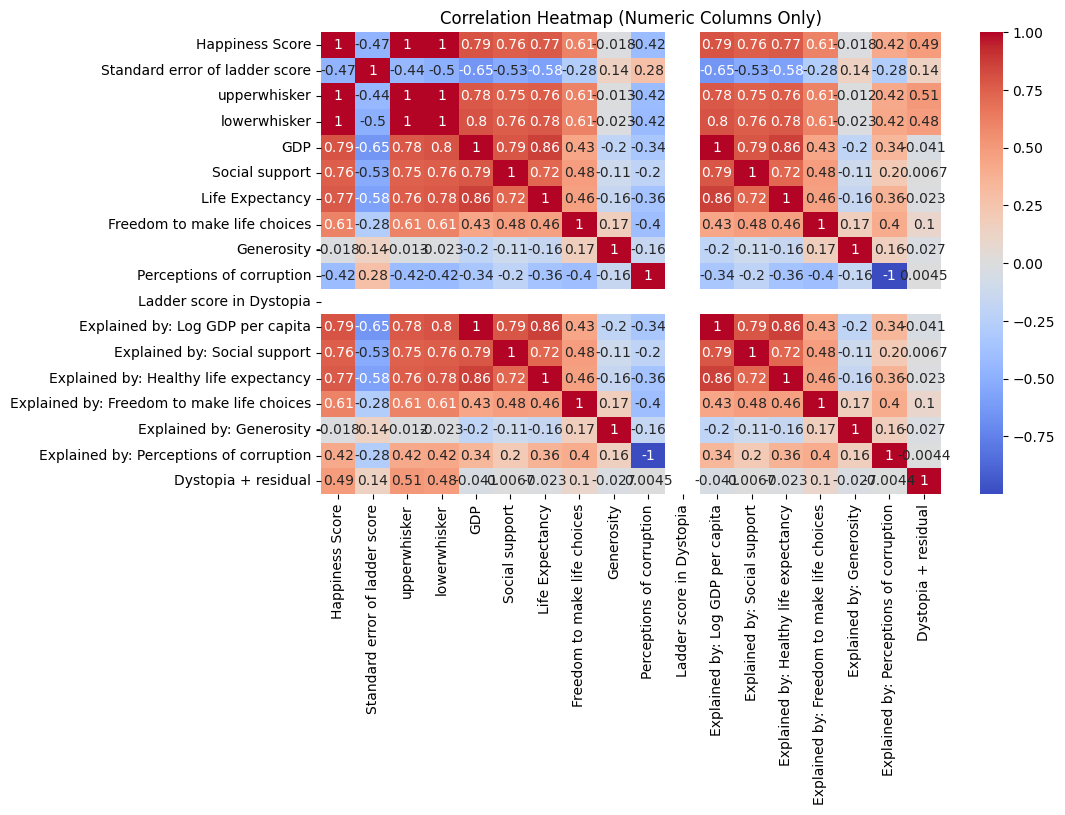

In [21]:
# Select only numeric columns for correlation
numeric_df = df.select_dtypes(include=['float64', 'int64'])

# Plot heatmap
plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap (Numeric Columns Only)')
plt.show()


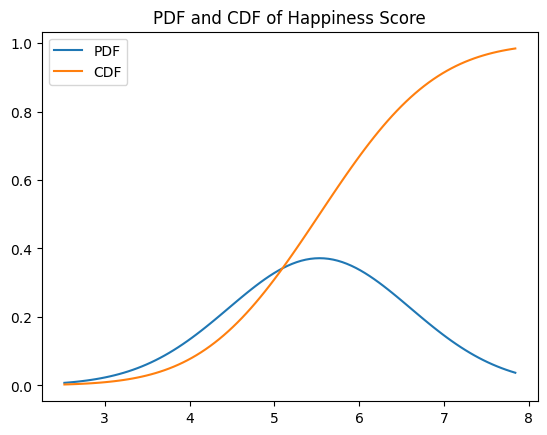

,Country,Regional indicator,Happiness Score,Standard error of ladder score,upperwhisker,lowerwhisker,GDP,Social support,Life Expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Ladder score in Dystopia,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
148,Afghanistan,South Asia,2.523,0.038,2.596,2.449,7.695,0.463,52.493,0.382,-0.102,0.924,2.43,0.37,0.0,0.126,0.0,0.122,0.01,1.895


<Figure size 640x480 with 0 Axes>

In [22]:
from scipy.stats import norm
import numpy as np

# PDF and CDF of Happiness Score
x = np.linspace(df['Happiness Score'].min(), df['Happiness Score'].max(), 100)
pdf = norm.pdf(x, df['Happiness Score'].mean(), df['Happiness Score'].std())
cdf = norm.cdf(x, df['Happiness Score'].mean(), df['Happiness Score'].std())

plt.plot(x, pdf, label='PDF')
plt.plot(x, cdf, label='CDF')
plt.title('PDF and CDF of Happiness Score')
plt.legend()
plt.show()
plt.savefig('PDF_CDF_of_happinessscore.png')  # Save as PNG

# Outlier Detection using IQR
Q1 = df['Happiness Score'].quantile(0.25)
Q3 = df['Happiness Score'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['Happiness Score'] < Q1 - 1.5 * IQR) | (df['Happiness Score'] > Q3 + 1.5 * IQR)]
outliers


Mean: 5.532838926174497
Median: 5.534
Mode: 5.477
Variance: 1.1533118252312715
Standard Deviation: 1.073923565823598
Skewness: -0.10426853999760208
Kurtosis: -0.36850162785429363


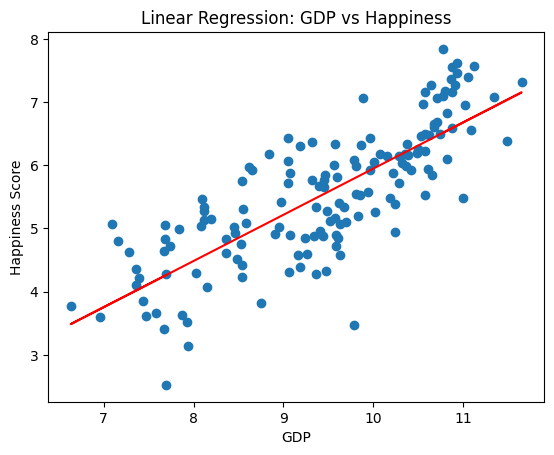

In [23]:
 #Univariate Analysis & Regression Analysis

# Basic Statistics
print("Mean:", df['Happiness Score'].mean())
print("Median:", df['Happiness Score'].median())
print("Mode:", df['Happiness Score'].mode()[0])
print("Variance:", df['Happiness Score'].var())
print("Standard Deviation:", df['Happiness Score'].std())
print("Skewness:", df['Happiness Score'].skew())
print("Kurtosis:", df['Happiness Score'].kurt())

# Regression (GDP → Happiness Score)
from sklearn.linear_model import LinearRegression

X = df[['GDP']]
y = df['Happiness Score']

model = LinearRegression()
model.fit(X, y)

# Plot regression line
plt.scatter(df['GDP'], y)
plt.plot(df['GDP'], model.predict(X), color='red')
plt.title('Linear Regression: GDP vs Happiness')
plt.xlabel('GDP')
plt.ylabel('Happiness Score')
plt.savefig('linear_regression_gdp_vs_happiness.png')  # Save as PNG
plt.show()


In [24]:
#Supervised Learning 
# Example: Predicting Happiness Score (Regression)
from sklearn.model_selection import train_test_split
from sklearn.metrics import  r2_score

features = ['GDP', 'Life Expectancy']
X = df[features]
y = df['Happiness Score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))



R2 Score: 0.5223217937036362


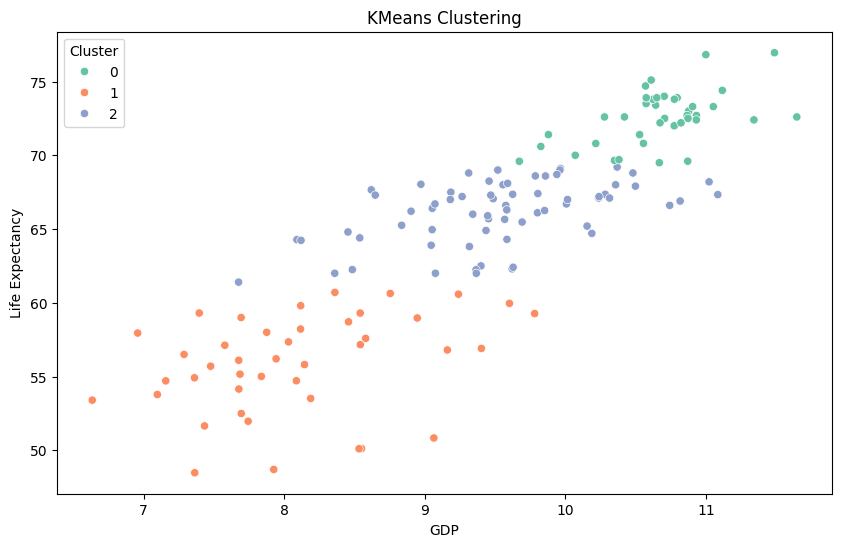

In [25]:
#UNspuervised using k-means Clustering
from sklearn.cluster import KMeans

X = df[['GDP', 'Life Expectancy']]
kmeans = KMeans(n_clusters=3)
df['Cluster'] = kmeans.fit_predict(X)

# Visualize Clusters
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='GDP', y='Life Expectancy', hue='Cluster', palette='Set2')
plt.title('KMeans Clustering')
plt.show()
